In [2]:
# Setup

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Import data
books_df = pd.read_csv('books.csv')
book_tags_df = pd.read_csv('book_tags.csv')
ratings_df = pd.read_csv('ratings.csv')
tags_df = pd.read_csv('tags.csv')
to_read_df = pd.read_csv('to_read.csv')

In [5]:
# Basic data profiling


def profile_df(df: pd.DataFrame):
    results = {
        "Info": df.info(),  # Prints to console

        "Describe": df.describe(),

        "Missing Values": df.isnull().sum()
    }

    print(results)





In [6]:
profile_df(tags_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34252 entries, 0 to 34251
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tag_id    34252 non-null  int64 
 1   tag_name  34252 non-null  object
dtypes: int64(1), object(1)
memory usage: 535.3+ KB
{'Info': None, 'Describe':              tag_id
count  34252.000000
mean   17125.500000
std     9887.845047
min        0.000000
25%     8562.750000
50%    17125.500000
75%    25688.250000
max    34251.000000, 'Missing Values': tag_id      0
tag_name    0
dtype: int64}


In [7]:
tags_df.tail()

,tag_id,tag_name
34247,34247,Ｃhildrens
34248,34248,Ｆａｖｏｒｉｔｅｓ
34249,34249,Ｍａｎｇａ
34250,34250,ＳＥＲＩＥＳ
34251,34251,ｆａｖｏｕｒｉｔｅｓ


In [8]:
profile_df(book_tags_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999912 entries, 0 to 999911
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   goodreads_book_id  999912 non-null  int64
 1   tag_id             999912 non-null  int64
 2   count              999912 non-null  int64
dtypes: int64(3)
memory usage: 22.9 MB
{'Info': None, 'Describe':        goodreads_book_id         tag_id          count
count       9.999120e+05  999912.000000  999912.000000
mean        5.263442e+06   16324.527073     208.869633
std         7.574057e+06    9647.846196    3501.265173
min         1.000000e+00       0.000000      -1.000000
25%         4.622700e+04    8067.000000       7.000000
50%         3.948410e+05   15808.000000      15.000000
75%         9.378297e+06   24997.000000      40.000000
max         3.328864e+07   34251.000000  596234.000000, 'Missing Values': goodreads_book_id    0
tag_id               0
count                0
dtype:

In [9]:
book_tags_df.head()

,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716


In [10]:
profile_df(books_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8916 non-null   object 
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int6

In [11]:
books_df.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [12]:
import functools as ft


book_tag_consolidated_df = ft.reduce(lambda left, right: pd.merge(left, right, on='goodreads_book_id'), [books_df, book_tags_df])
book_tag_consolidated_df = ft.reduce(lambda left, right: pd.merge(left, right, on='tag_id'), [book_tag_consolidated_df, tags_df])


profile_df(book_tag_consolidated_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999912 entries, 0 to 999911
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   book_id                    999912 non-null  int64  
 1   goodreads_book_id          999912 non-null  int64  
 2   best_book_id               999912 non-null  int64  
 3   work_id                    999912 non-null  int64  
 4   books_count                999912 non-null  int64  
 5   isbn                       929994 non-null  object 
 6   isbn13                     941494 non-null  float64
 7   authors                    999912 non-null  object 
 8   original_publication_year  997812 non-null  float64
 9   original_title             941462 non-null  object 
 10  title                      999912 non-null  object 
 11  language_code              891518 non-null  object 
 12  average_rating             999912 non-null  float64
 13  ratings_count              99

In [13]:
book_tag_consolidated_df.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,tag_id,count,tag_name
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,11557,50755,favorites
1,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,8717,35418,currently-reading
2,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,33114,25968,young-adult
3,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,11743,13819,fiction
4,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,10064,12985,dystopian


C:\Users\mili\AppData\Local\Temp\1\ipykernel_4572\1024239747.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['original_publication_year'] = df['original_publication_year'].astype(int)


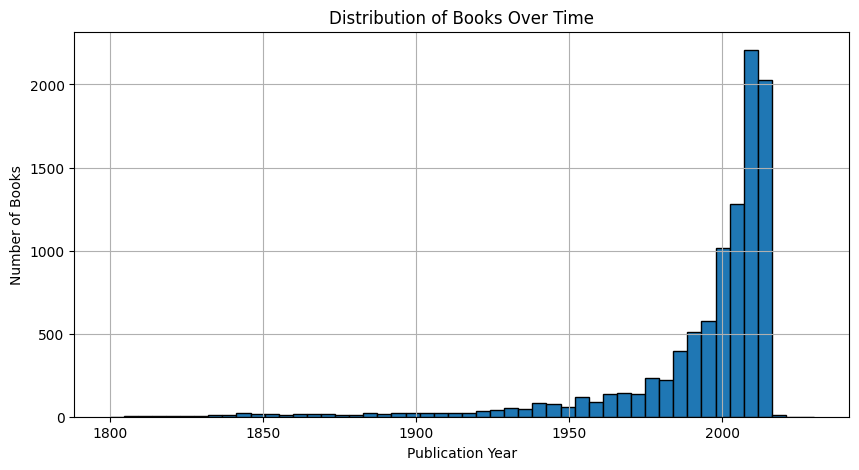

In [14]:
# Drop NaN values in the 'original_publication_year' column
df = books_df.dropna(subset=['original_publication_year'])

# Convert to integer
df['original_publication_year'] = df['original_publication_year'].astype(int)

# Plot the histogram
plt.figure(figsize=(10, 5))
plt.hist(df['original_publication_year'], bins=50, range=(1800, 2030), edgecolor='black')
plt.xlabel("Publication Year")
plt.ylabel("Number of Books")
plt.title("Distribution of Books Over Time")
plt.grid(True)
plt.show()

C:\Users\mili\AppData\Local\Temp\1\ipykernel_4572\3061066521.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ratings_variance'] = books_df[['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']].var(axis=1)


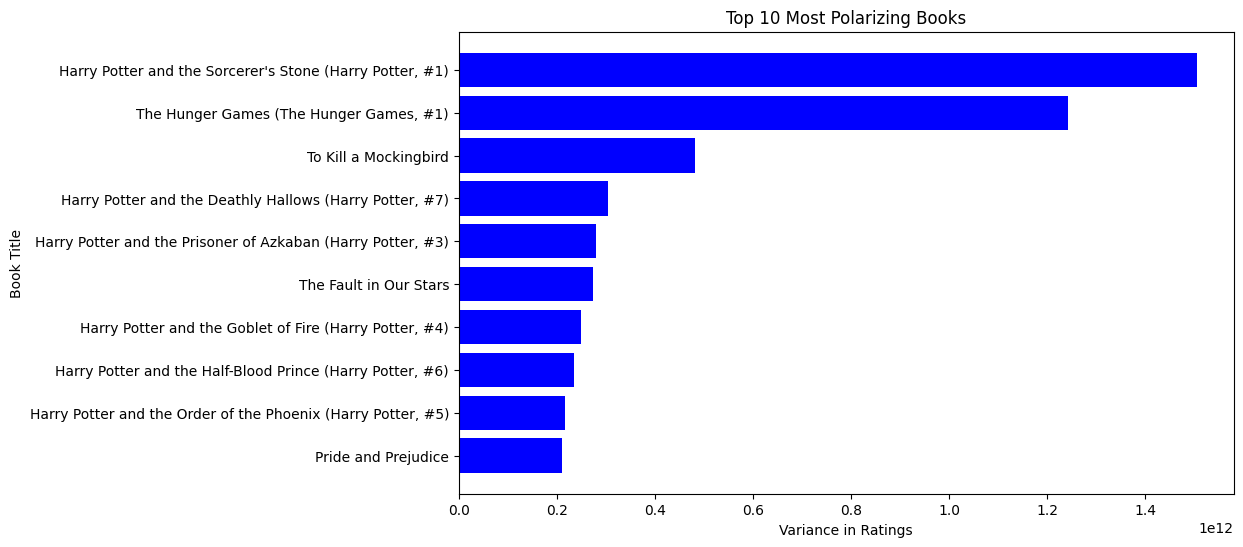

'\nNEXT STEPS\n- could be due to review bombing\n- check for multimodal reviews for polarizing books\n- look into statistical tests for normality\n\n\n\nBIG NEXT STEPS\n- cluster analysis\n'

In [19]:
# Calculate variance of ratings for each book
df['ratings_variance'] = books_df[['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']].var(axis=1)

# Get the top 10 books with the highest variance
polarizing_books = df.nlargest(10, 'ratings_variance')

# Plot
plt.figure(figsize=(10, 6))
plt.barh(polarizing_books['title'], polarizing_books['ratings_variance'], color='blue')
plt.xlabel("Variance in Ratings")
plt.ylabel("Book Title")
plt.title("Top 10 Most Polarizing Books")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()


'''
NEXT STEPS
- could be due to review bombing
- check for multimodal reviews for polarizing books
- look into statistical tests for normality



BIG NEXT STEPS
- cluster analysis
'''

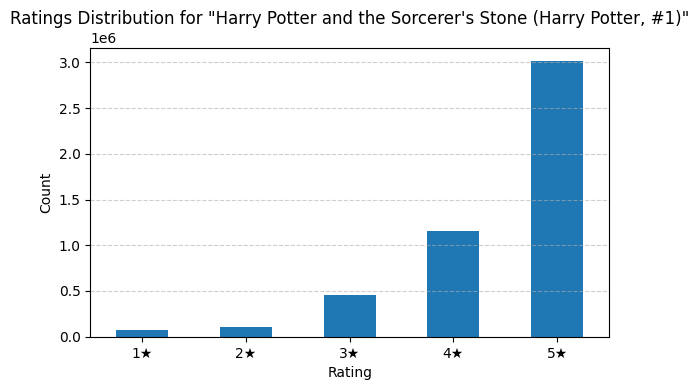

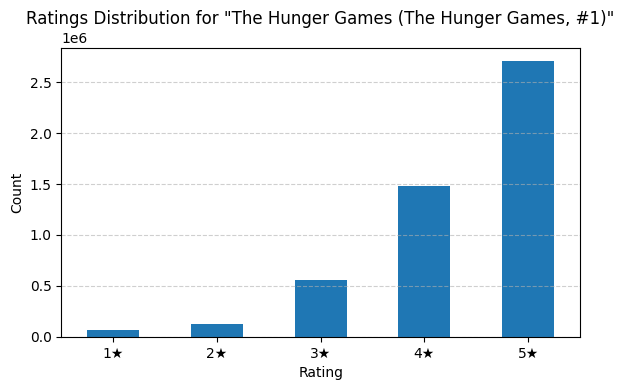

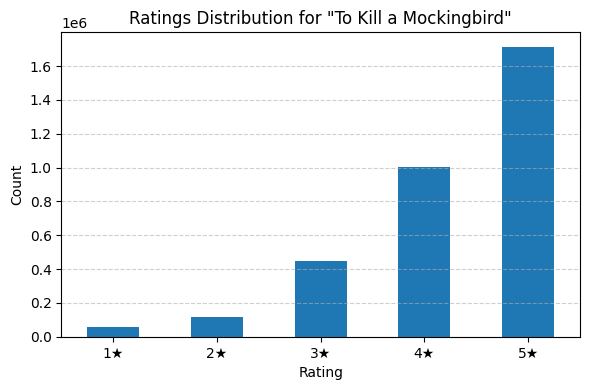

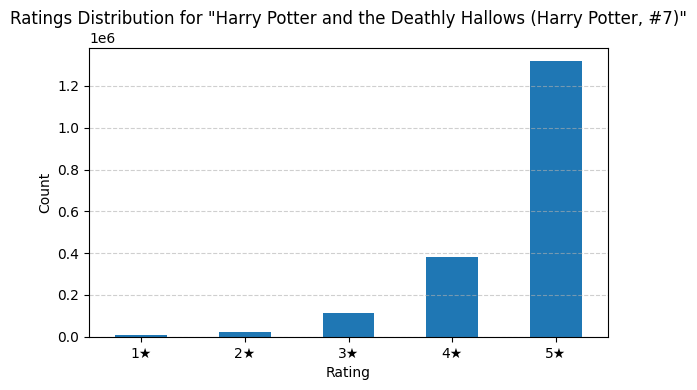

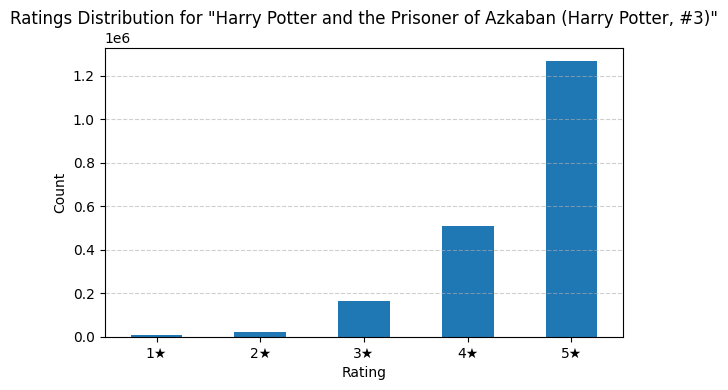

In [18]:
# - check for multimodal reviews for polarizing books

top_5_polarizing_books = polarizing_books.head()



# Plot a histogram for each book
for i, row in top_5_polarizing_books.iterrows():
    ratings = row[['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']]
    plt.figure(figsize=(6, 4))
    ratings.plot(kind='bar')
    plt.title(f'Ratings Distribution for "{row["title"]}"')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.xticks(ticks=range(5), labels=['1★', '2★', '3★', '4★', '5★'], rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()